## Exploring predictions

In [1]:
import sys
import gc
import random
import importlib as imp
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf

import experiment_settings
import build_model
import train_model
import build_data

from sklearn.metrics import mean_squared_error, mean_absolute_error

In [2]:
print(f"python version = {sys.version}")
print(f"numpy version = {np.__version__}")
print(f"tensorflow version = {tf.__version__}")  

tf.config.set_visible_devices([], "GPU")  # turn-off tensorflow-metal if it is on
# print(tf.config.list_physical_devices('GPU'))

python version = 3.10.10 | packaged by conda-forge | (main, Mar 24 2023, 20:12:31) [Clang 14.0.6 ]
numpy version = 1.23.2
tensorflow version = 2.10.0


In [3]:
# GET SETTINGS
EXP_NAME = "exp0"
settings = experiment_settings.get_settings(EXP_NAME)

SAVE_MODEL_DIRECTORY = "saved_models/"

# SET RANDOM SEEDS
np.random.seed(settings["rng_seed"])
random.seed(settings["rng_seed"])
tf.random.set_seed(settings["rng_seed"])



In [4]:
imp.reload(build_data)

settings_test = settings.copy()
settings_test["batch_size"] = 128
settings_test["nbatches"] = (50, 0)
settings_test["training"] = False

(tagyear_test, 
taglat_test, 
taglon_test,
__, __, __, __,
) = build_data.make_sample_list(settings_test, evaluate_all=False)

tfds_test = build_data.build_tf_dataset(settings_test, tagyear_test, taglat_test, taglon_test, settings_test["batch_size"], shuffle=False)
tfds_test = tfds_test.prefetch(tf.data.AUTOTUNE)

batch_shape = np.shape(next(tfds_test.as_numpy_iterator())[0])
print(f"{batch_shape = }")


output region shape = (327, 327)
ntrain = 6400, nval = 0
batch_shape = (128, 114, 114, 6)


In [5]:
imp.reload(build_model)
imp.reload(train_model)

tf.keras.backend.clear_session()
model = build_model.build_model(settings, input_shape=batch_shape[1:])

checkpoint_dir = SAVE_MODEL_DIRECTORY + settings["exp_name"] + '/'
model.load_weights(tf.train.latest_checkpoint(checkpoint_dir))

labels_test = np.asarray([labels[0].numpy() for _, labels in tfds_test.unbatch()])
predict_test = model.predict(tfds_test, verbose=1)[:,0]
__ = gc.collect()

50/50 [==============================] - 22s 429ms/step


(6400,) (6400,)


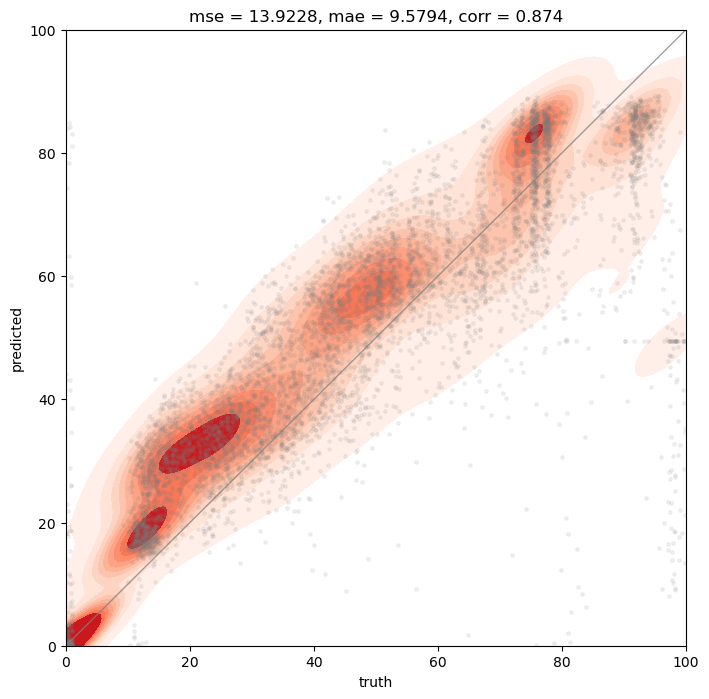

In [8]:
import seaborn as sns

print(labels_test.shape, predict_test.shape)
mse = np.sqrt(mean_squared_error(labels_test, predict_test)).round(4)
mae = mean_absolute_error(labels_test, predict_test).round(4)
corr = np.corrcoef(labels_test, predict_test)[0,1].round(4)

plt.figure(figsize=(8,8))

sns.kdeplot(x=labels_test, y=predict_test, fill=True, cmap="Reds", bw_adjust=.75)
plt.plot(labels_test + np.random.uniform(size=labels_test.shape[0]), predict_test, '.', color="gray", markersize=5, alpha=.1)
plt.plot((0,100), (0,100), '-', linewidth=1, color="gray", alpha=.75)

plt.title(f'{mse = }, {mae = }, {corr = }')
plt.xlabel('truth')
plt.ylabel('predicted')
plt.xlim(0,100)
plt.ylim(0,100)
plt.show()